In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\ruthe\Documents Local\Adelphe Connect\fife_industry_data.csv")

In [3]:
df.head()

,Industry,Age,Sex,Region,People
0,Agriculture; Forestry; Fishing,Total,Female,Fife,551
1,Agriculture; Forestry; Fishing,16 to 19,Female,Fife,15
2,Agriculture; Forestry; Fishing,20 to 24,Female,Fife,32
3,Agriculture; Forestry; Fishing,25 to 29,Female,Fife,35
4,Agriculture; Forestry; Fishing,30 to 34,Female,Fife,55


# Top 3 Industries with the most women

In [4]:
df.loc[(df['Age'] == 'Total') & (df['Sex'] == 'Female')].sort_values(by='People', ascending=False).head(3)[['Industry','People']]

,Industry,People
256,Human Health and Social Work Activities,20489
240,Education,10658
96,Wholesale and Retail trade; Repair of Motor Ve...,10349


In [26]:
# Make dataframe of just the totals for each industry and sex
# We will separate the Sex column into two new columns: Female_workers and Male_workers
industry_totals = df.loc[(df['Sex'] == 'Female') & (df['Age'] == 'Total')][['Industry', 'People']]
industry_totals.rename(columns={'People': 'Female_workers'}, inplace=True)
industry_totals.set_index('Industry', inplace=True)
industry_totals = pd.merge(industry_totals, df.loc[(df['Sex'] == 'Male') & (df['Age'] == 'Total')][['Industry', 'People']].set_index('Industry'),left_index=True,right_index=True, how='outer')
industry_totals.rename(columns={'People':'Male_workers'}, inplace=True)
# Remove homecarer work
industry_totals.drop('Activities of Household as Employers; Undifferentiated Goods - and Services - Producing Activities of Households for Own Use', inplace=True)

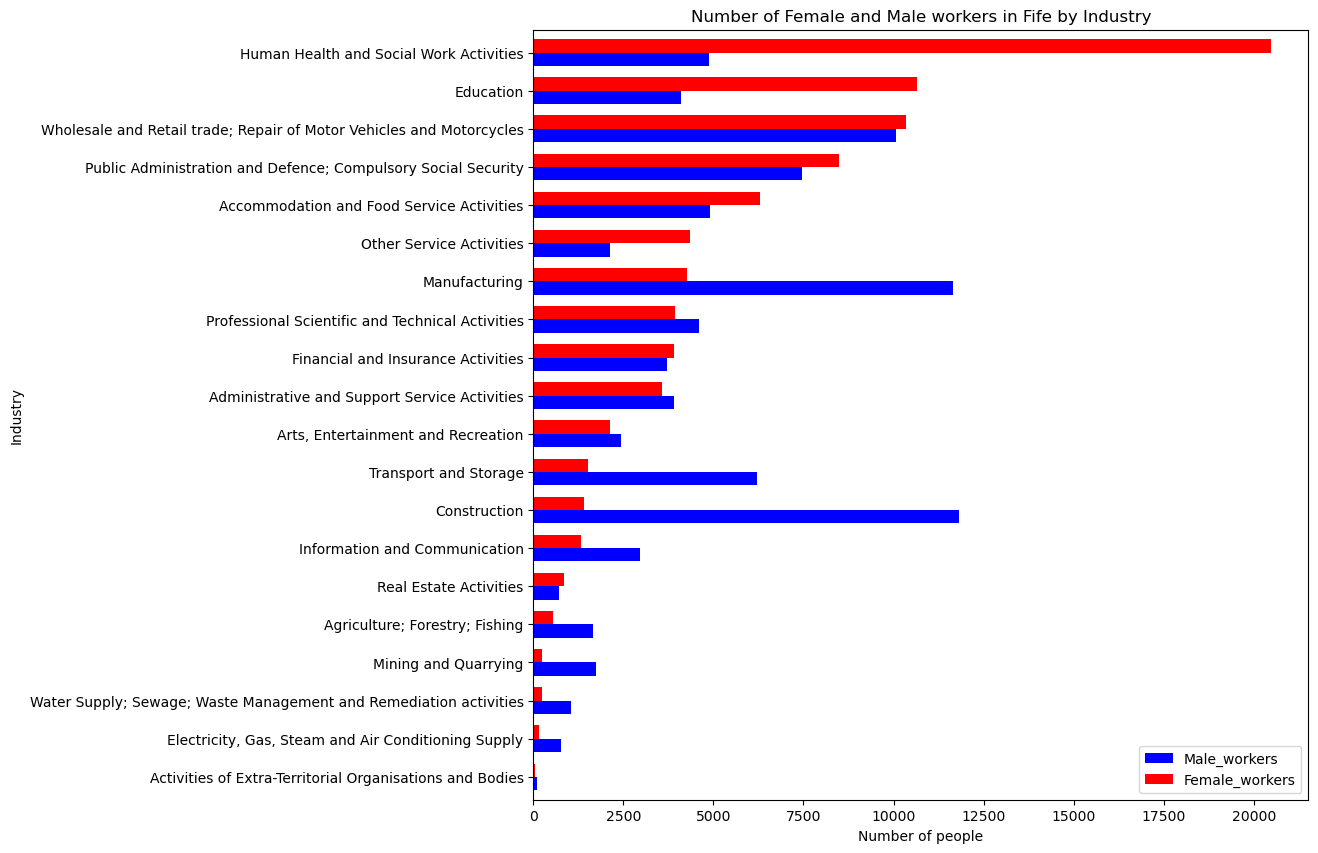

In [40]:
fig, ax = plt.subplots(figsize=(10,10))

industry_totals.sort_values(by='Female_workers', ascending=True, inplace=True)
industry_totals.plot.barh(width=0.7, y=['Male_workers', 'Female_workers'], stacked=False, ax=ax, color={"Female_workers": "red", "Male_workers": "blue"})

ax.set_title('Number of Female and Male workers in Fife by Industry')
ax.set_ylabel('Industry')
ax.set_xlabel('Number of people')
ax.legend()

plt.show()